# Evaluation result for LIGHTGBM


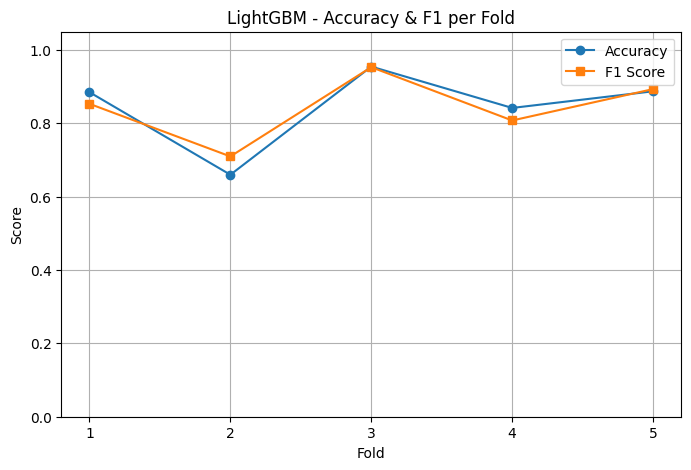

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# Path to saved metrics JSON
json_path = "../cicids2017/results/lgb_metrics.json"  

with open(json_path, "r") as f:
    metrics_all = json.load(f)

# Check structure
list(metrics_all.keys())

model_name = "LightGBM"  # replace as needed
folds = metrics_all[model_name]

# Extract metrics
accuracy = [fold['accuracy'] for fold in folds]
f1_score_vals = [fold['f1'] for fold in folds]

# Plot Accuracy
plt.figure(figsize=(8,5))
plt.plot(range(1, len(accuracy)+1), accuracy, marker='o', label='Accuracy')
plt.plot(range(1, len(f1_score_vals)+1), f1_score_vals, marker='s', label='F1 Score')
plt.title(f'{model_name} - Accuracy & F1 per Fold')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.ylim(0,1.05)
plt.xticks(range(1, len(accuracy)+1))
plt.grid(True)
plt.legend()
plt.show()


In [3]:
avg_accuracy = np.mean([fold['accuracy'] for fold in folds])
avg_f1 = np.mean([fold['f1'] for fold in folds])
avg_precision = np.mean([fold['precision'] for fold in folds])
avg_recall = np.mean([fold['recall'] for fold in folds])
avg_roc_auc = np.mean([fold['roc_auc'] for fold in folds if fold['roc_auc'] is not None])

print(f"{model_name} - Average Metrics Across {len(folds)} Folds")
print(f"Accuracy: {avg_accuracy:.4f}")
print(f"F1 Score: {avg_f1:.4f}")
print(f"Precision: {avg_precision:.4f}")
print(f"Recall: {avg_recall:.4f}")
print(f"ROC AUC: {avg_roc_auc:.4f}")


LightGBM - Average Metrics Across 5 Folds
Accuracy: 0.8459
F1 Score: 0.8436
Precision: 0.8813
Recall: 0.8459
ROC AUC: 0.5774


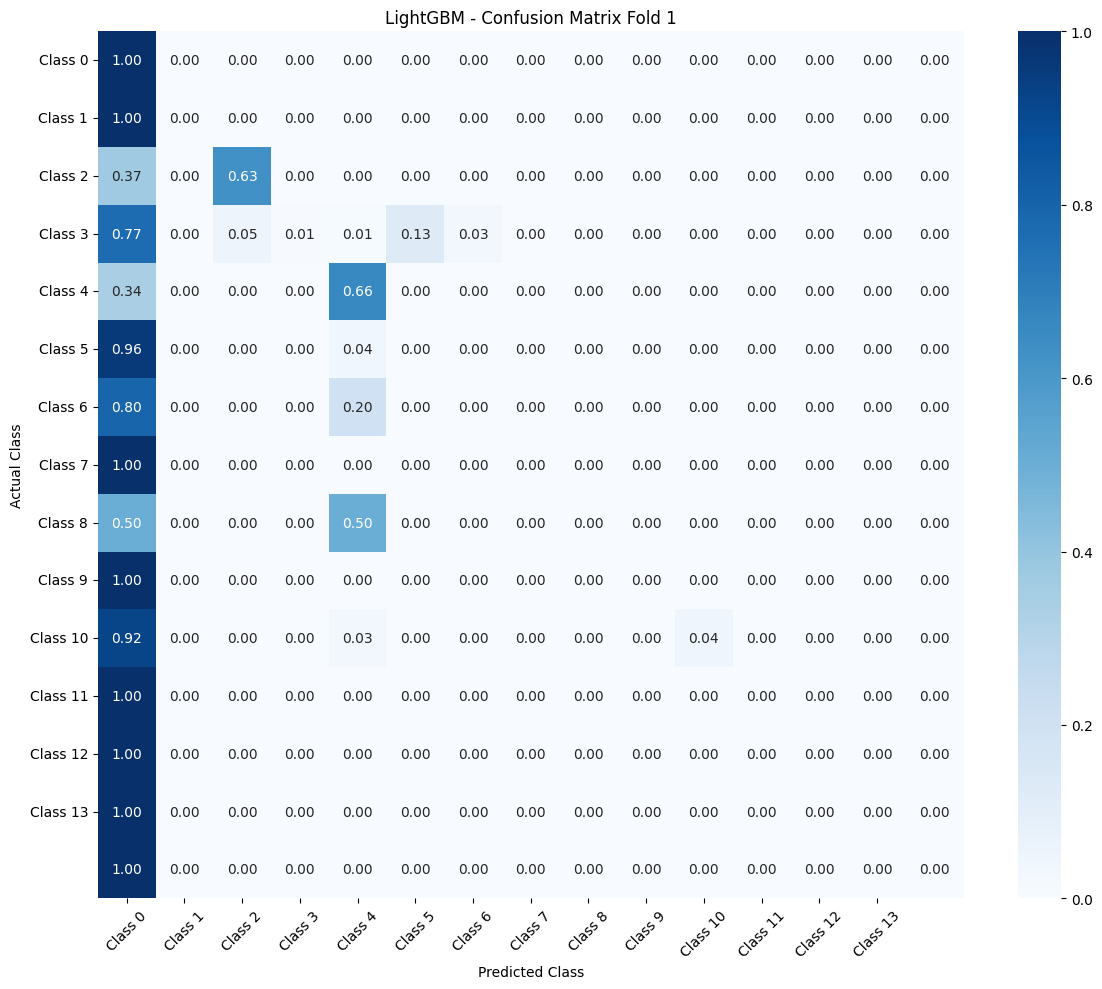

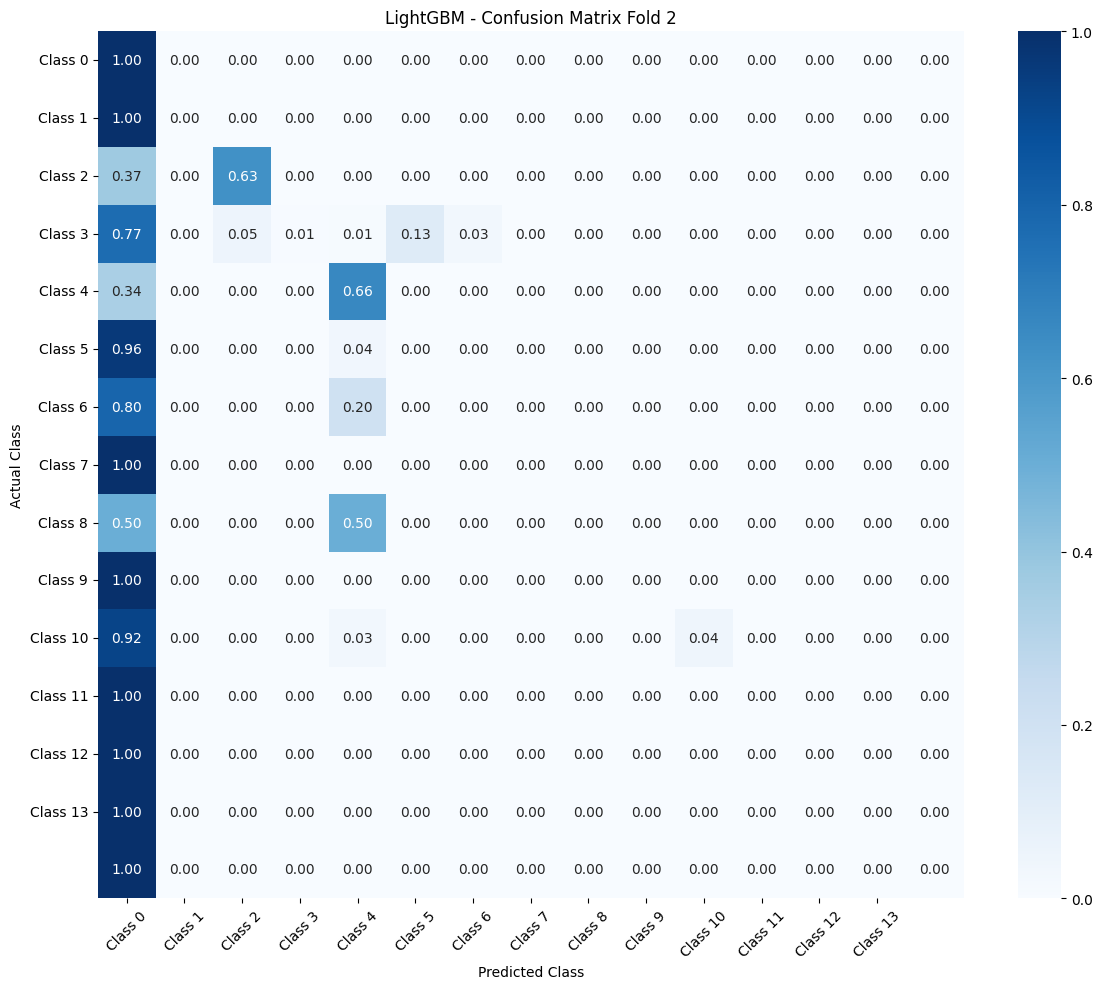

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(cm, class_names=None, fold_num=1, model_name="Model", normalize=True):
    """
    cm: confusion matrix (numpy array)
    class_names: list of class labels
    fold_num: fold number for title
    model_name: name of the model
    normalize: whether to normalize by row (per-class)
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(12,10))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d", cmap="Blues", cbar=True,
                xticklabels=class_names, yticklabels=class_names)
    
    plt.title(f"{model_name} - Confusion Matrix Fold {fold_num}")
    plt.ylabel("Actual Class")
    plt.xlabel("Predicted Class")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
# Example usage:
fold_num = 1
cm = np.array(metrics_all['LightGBM'][fold_num-1]['confusion_matrix'])
class_names = [f"Class {i}" for i in range(14)]  # replace with your actual class names if you have
plot_confusion_matrix(cm, class_names=class_names, fold_num=fold_num, model_name="LightGBM")

fold_num = 2
cm = np.array(metrics_all['LightGBM'][fold_num-2]['confusion_matrix'])
class_names = [f"Class {i}" for i in range(14)]  # replace with your actual class names if you have
plot_confusion_matrix(cm, class_names=class_names, fold_num=fold_num, model_name="LightGBM")



# Evaluation result for LIGHTGBM after hyperparameter tuning


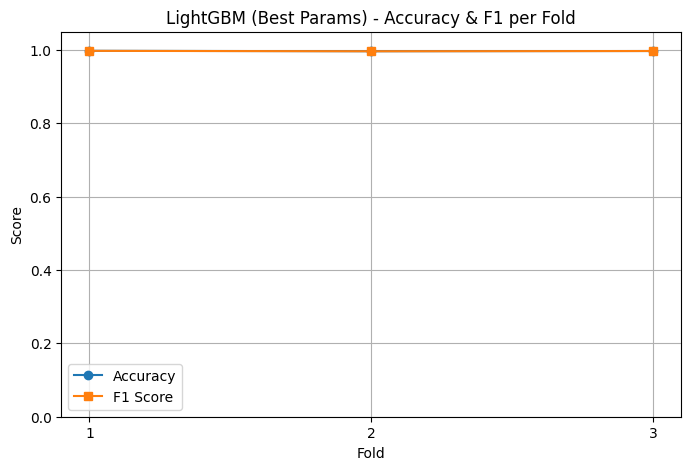

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# ---- Load Metrics ----
json_path = "../cicids2017/results/lgb_best_metrics.json"  # updated file

with open(json_path, "r") as f:
    metrics_all = json.load(f)

# There is only one model in this metrics file → get the name dynamically
model_name = list(metrics_all.keys())[0]
folds = metrics_all[model_name]

# ---- Extract Metrics ----
accuracy = [fold['accuracy'] for fold in folds]
f1_score_vals = [fold['f1'] for fold in folds]

# ---- Plot Accuracy & F1 ----
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(accuracy) + 1), accuracy, marker='o', label='Accuracy')
plt.plot(range(1, len(f1_score_vals) + 1), f1_score_vals, marker='s', label='F1 Score')

plt.title(f'{model_name} (Best Params) - Accuracy & F1 per Fold')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(range(1, len(accuracy) + 1))
plt.grid(True)
plt.legend()
plt.show()


In [8]:
avg_accuracy = np.mean([fold['accuracy'] for fold in folds])
avg_f1 = np.mean([fold['f1'] for fold in folds])
avg_precision = np.mean([fold['precision'] for fold in folds])
avg_recall = np.mean([fold['recall'] for fold in folds])
avg_roc_auc = np.mean([fold['roc_auc'] for fold in folds if fold['roc_auc'] is not None])

print(f"{model_name} - Average Metrics Across {len(folds)} Folds")
print(f"Accuracy: {avg_accuracy:.4f}")
print(f"F1 Score: {avg_f1:.4f}")
print(f"Precision: {avg_precision:.4f}")
print(f"Recall: {avg_recall:.4f}")
print(f"ROC AUC: {avg_roc_auc:.4f}")


LightGBM - Average Metrics Across 3 Folds
Accuracy: 0.9974
F1 Score: 0.9973
Precision: 0.9974
Recall: 0.9974
ROC AUC: 0.9279


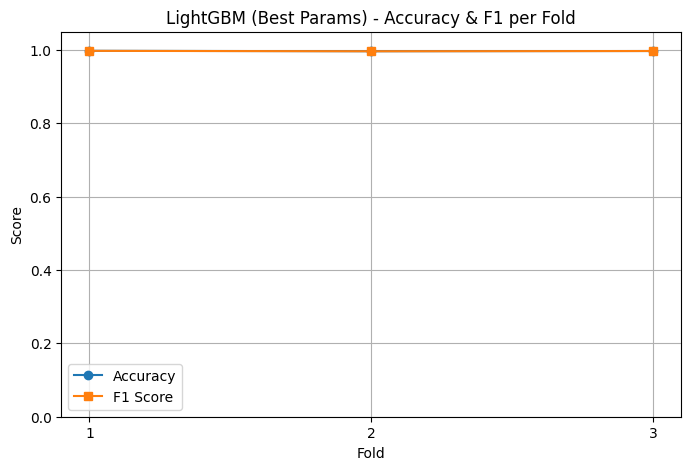


===== METRICS SUMMARY TABLE =====
   Fold  Accuracy  Precision    Recall  F1 Score
0     1  0.997924   0.997922  0.997924  0.997789
1     2  0.996822   0.996702  0.996822  0.996689
2     3  0.997393   0.997640  0.997393  0.997365

AVERAGES:
Fold         2.000000
Accuracy     0.997379
Precision    0.997421
Recall       0.997379
F1 Score     0.997281
dtype: float64


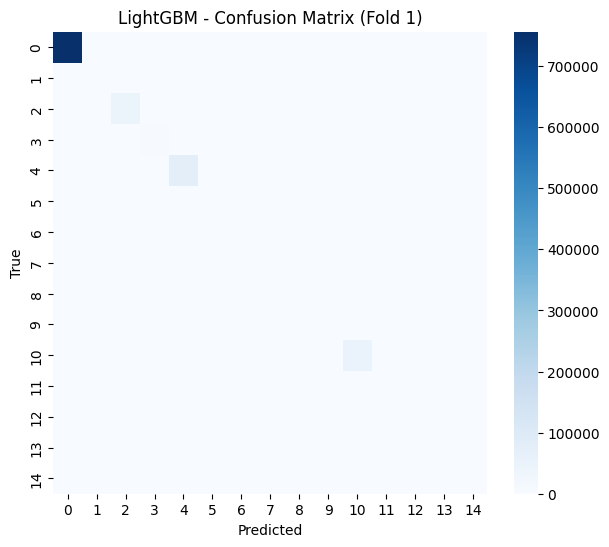

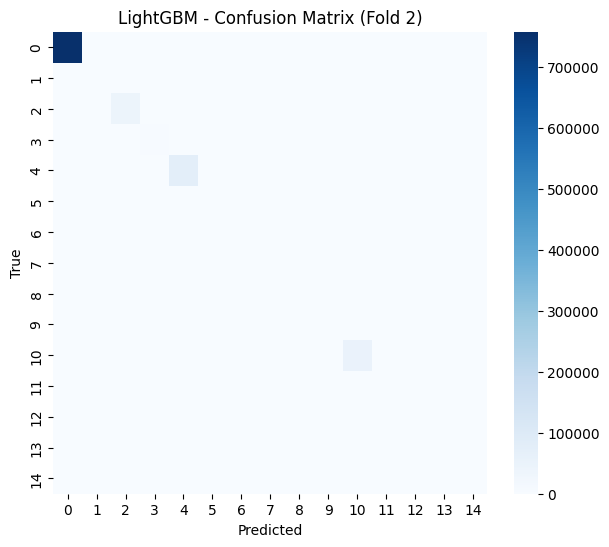

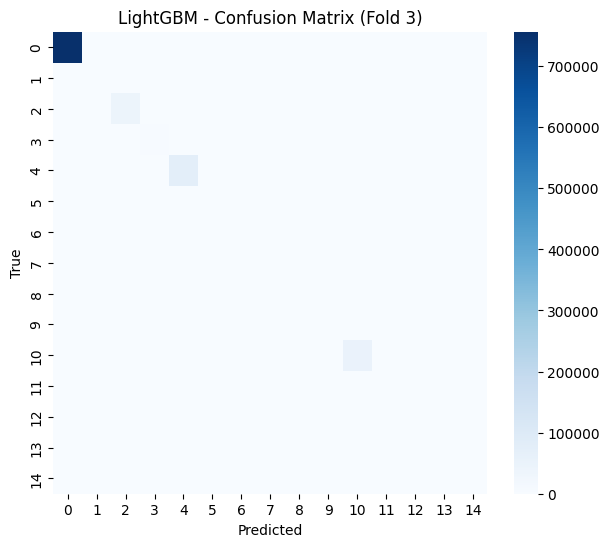

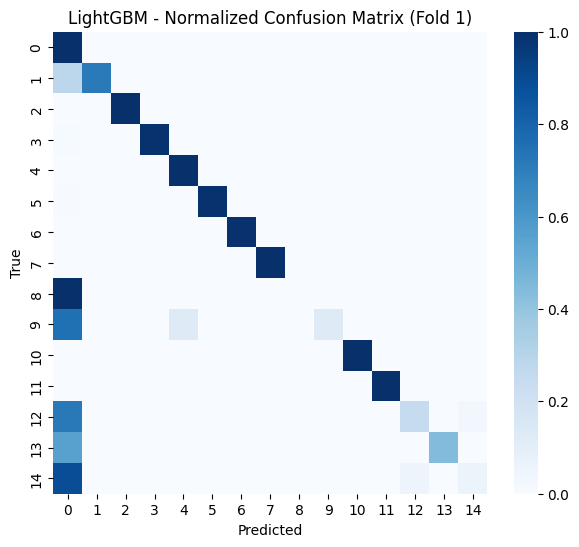

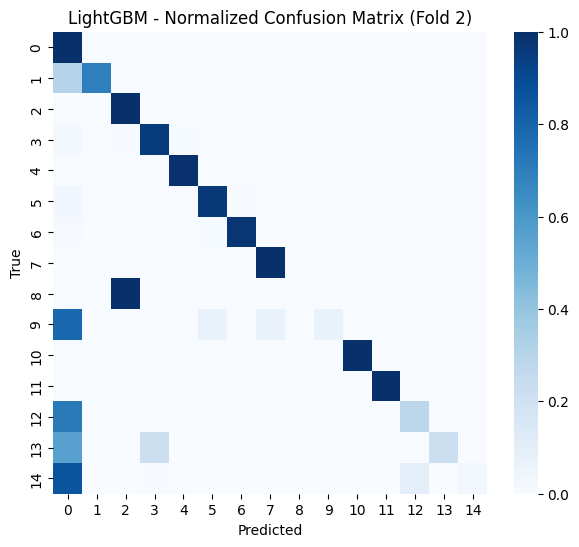

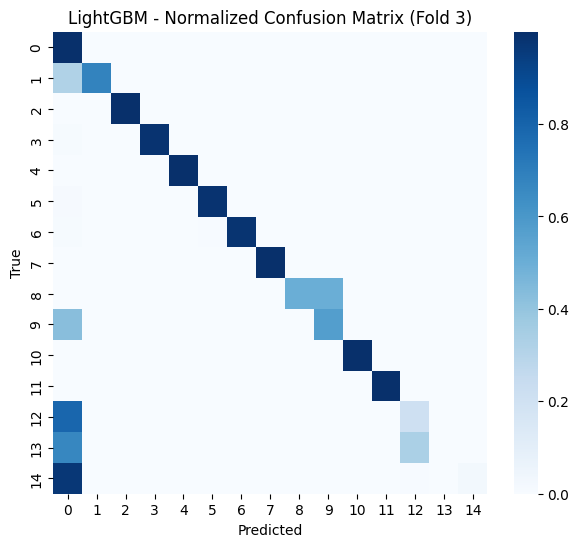

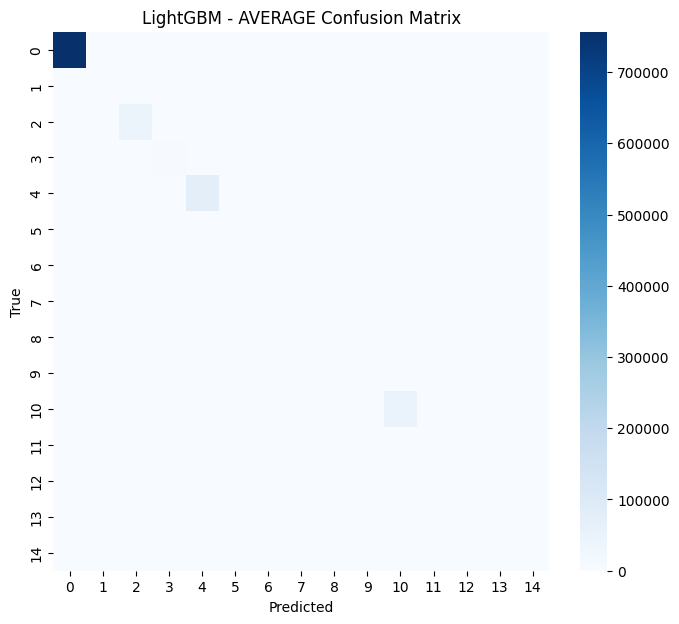

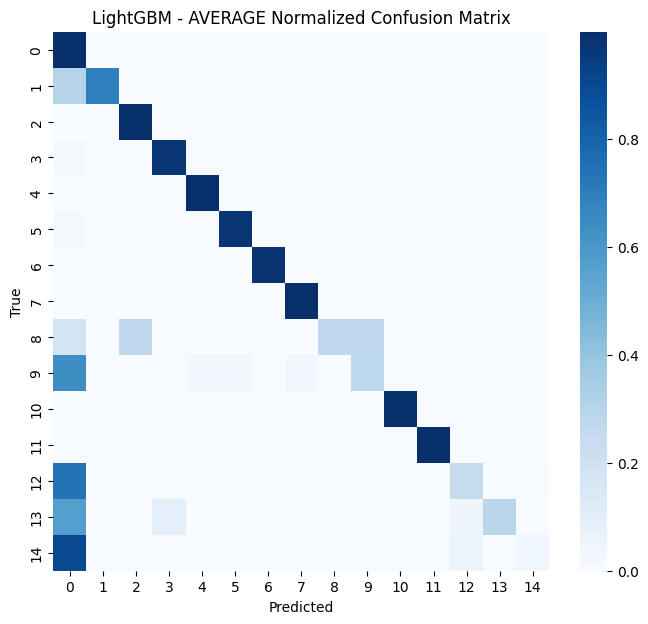

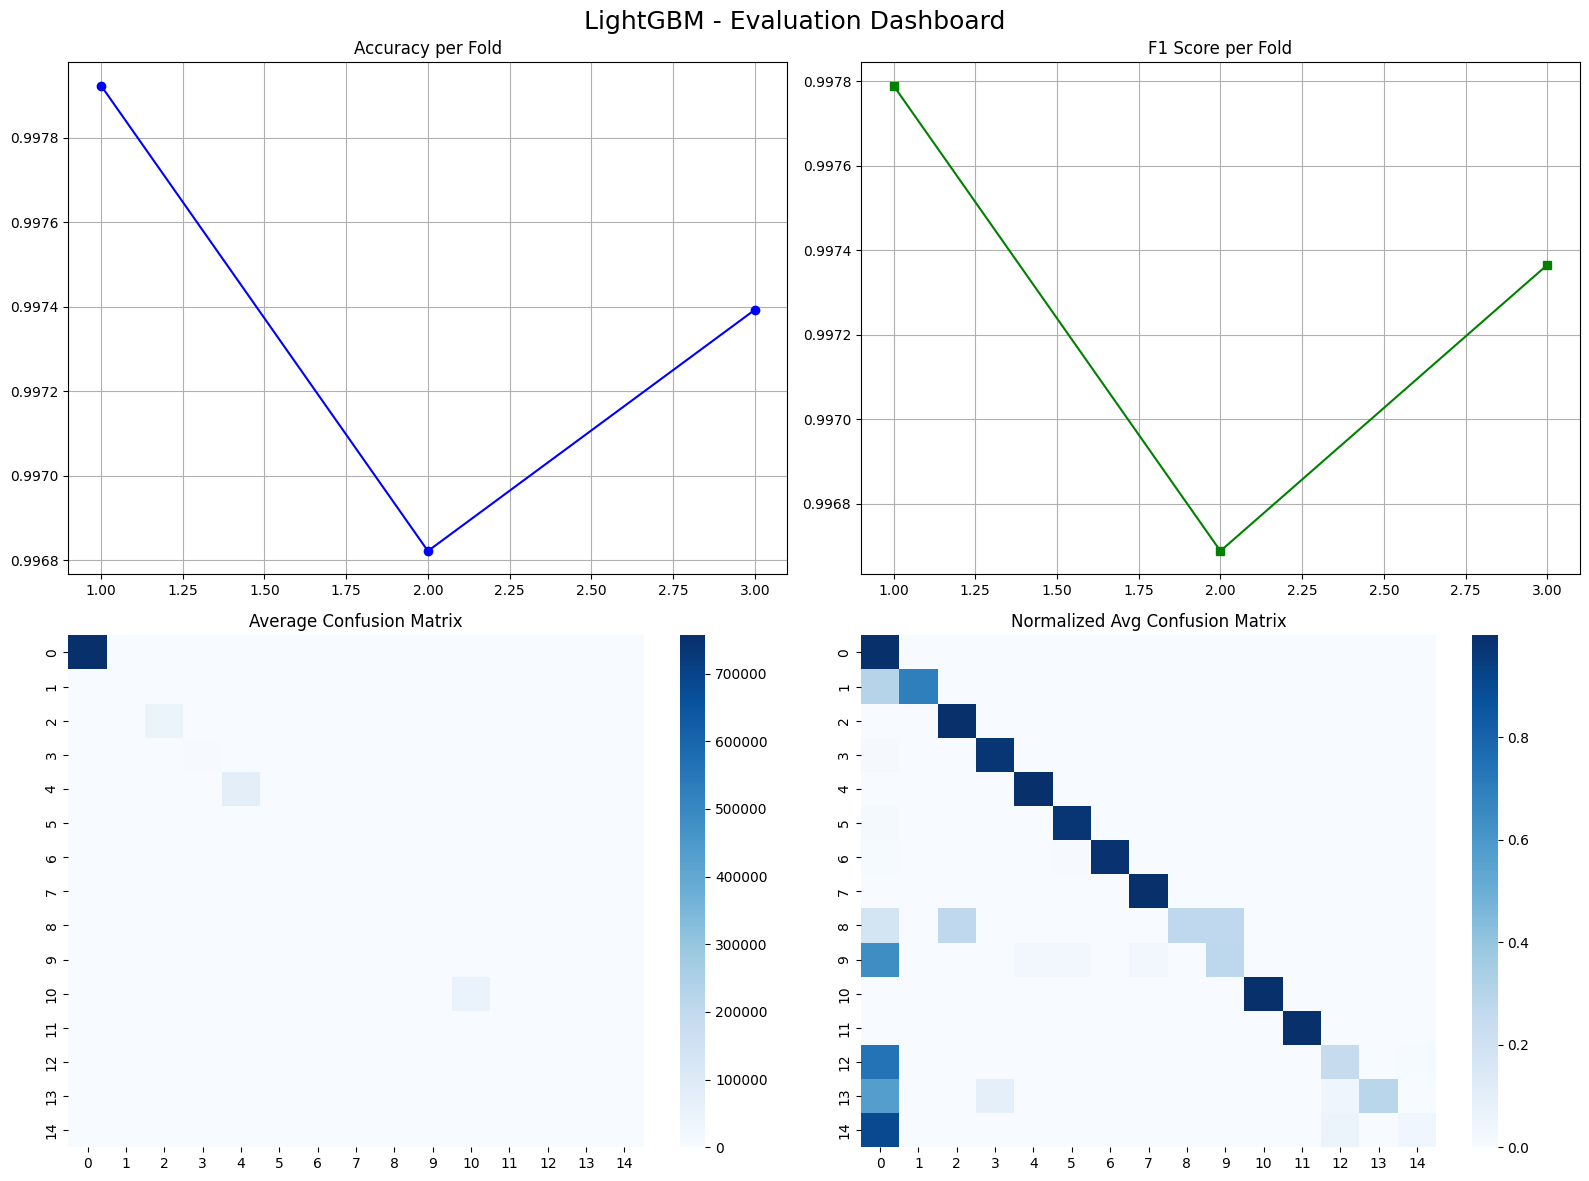

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ------------------------------------------------------------
# LOAD METRICS JSON
# ------------------------------------------------------------
json_path = "../cicids2017/results/lgb_best_metrics.json"

with open(json_path, "r") as f:
    metrics_all = json.load(f)

model_name = list(metrics_all.keys())[0]   # auto-detect
folds = metrics_all[model_name]
n_folds = len(folds)

# ------------------------------------------------------------
# EXTRACT METRICS
# ------------------------------------------------------------
accuracy = [fold['accuracy'] for fold in folds]
precision = [fold['precision'] for fold in folds]
recall = [fold['recall'] for fold in folds]
f1_vals = [fold['f1'] for fold in folds]

conf_matrices = [np.array(fold["confusion_matrix"]) for fold in folds]

# ------------------------------------------------------------
# 1️⃣ ACCURACY & F1 SCORE LINE PLOT
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_folds+1), accuracy, marker='o', label='Accuracy')
plt.plot(range(1, n_folds+1), f1_vals, marker='s', label='F1 Score')

plt.title(f"{model_name} (Best Params) - Accuracy & F1 per Fold")
plt.xlabel("Fold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(True)
plt.xticks(range(1, n_folds+1))
plt.legend()
plt.show()

# ------------------------------------------------------------
# 2️⃣ METRICS SUMMARY TABLE (Pandas)
# ------------------------------------------------------------
summary_df = pd.DataFrame({
    "Fold": list(range(1, n_folds+1)),
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1_vals
})

print("\n===== METRICS SUMMARY TABLE =====")
print(summary_df)
print("\nAVERAGES:")
print(summary_df.mean())

# ------------------------------------------------------------
# 3️⃣ CONFUSION MATRIX PER FOLD (HEATMAP)
# ------------------------------------------------------------
for i, cm in enumerate(conf_matrices, start=1):
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, cmap="Blues", annot=False)
    plt.title(f"{model_name} - Confusion Matrix (Fold {i})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# ------------------------------------------------------------
# 4️⃣ NORMALIZED CONFUSION MATRIX (PER FOLD)
# ------------------------------------------------------------
for i, cm in enumerate(conf_matrices, start=1):
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm_norm, cmap="Blues", annot=False)
    plt.title(f"{model_name} - Normalized Confusion Matrix (Fold {i})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# ------------------------------------------------------------
# 5️⃣ AVERAGE CONFUSION MATRIX
# ------------------------------------------------------------
avg_cm = np.mean(conf_matrices, axis=0)

plt.figure(figsize=(8, 7))
sns.heatmap(avg_cm, cmap="Blues", annot=False)
plt.title(f"{model_name} - AVERAGE Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Normalized version
avg_cm_norm = avg_cm / avg_cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 7))
sns.heatmap(avg_cm_norm, cmap="Blues", annot=False)
plt.title(f"{model_name} - AVERAGE Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ------------------------------------------------------------
# 6️⃣ FULL DASHBOARD — 1 FIGURE WITH SUBPLOTS
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Accuracy
axes[0, 0].plot(range(1, n_folds+1), accuracy, marker='o', color='blue')
axes[0, 0].set_title("Accuracy per Fold")
axes[0, 0].grid(True)

# F1
axes[0, 1].plot(range(1, n_folds+1), f1_vals, marker='s', color='green')
axes[0, 1].set_title("F1 Score per Fold")
axes[0, 1].grid(True)

# Average Confusion Matrix
sns.heatmap(avg_cm, ax=axes[1, 0], cmap="Blues", annot=False)
axes[1, 0].set_title("Average Confusion Matrix")

# Normalized Average Confusion Matrix
sns.heatmap(avg_cm_norm, ax=axes[1, 1], cmap="Blues", annot=False)
axes[1, 1].set_title("Normalized Avg Confusion Matrix")

plt.suptitle(f"{model_name} - Evaluation Dashboard", fontsize=18)
plt.tight_layout()
plt.show()


In [ ]:

import pandas as pd
from sklearn.preprocessing import LabelEncoder

DATA_PATH = "../datasets/cicids2017/finalprocessed.csv"

df = pd.read_csv(DATA_PATH)

# Separate X and y
X = df.drop("Label", axis=1)   # <-- change "label" to your actual label column name
y_raw = df["Label"]

# Encode labels (same as training)
le = LabelEncoder()
y = le.fit_transform(y_raw)

print("Shape of X:", X.shape)
print("Number of classes:", len(le.classes_))


Shape of X: (2830743, 28)
Number of classes: 15


In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import os

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from itertools import cycle

# Paths
RESULTS_DIR = "../cicids2017/results/"
MODEL_PATH = os.path.join(RESULTS_DIR, "lgb_best_model.pkl")
METRICS_PATH = os.path.join(RESULTS_DIR, "lgb_best_metrics.json")

# Load model
lgb_best = joblib.load(MODEL_PATH)

# Load data (you already know how)
# X, y = ...

# Binarize labels for ROC / PR
y_bin = label_binarize(y, classes=np.unique(y))
n_classes = y_bin.shape[1]


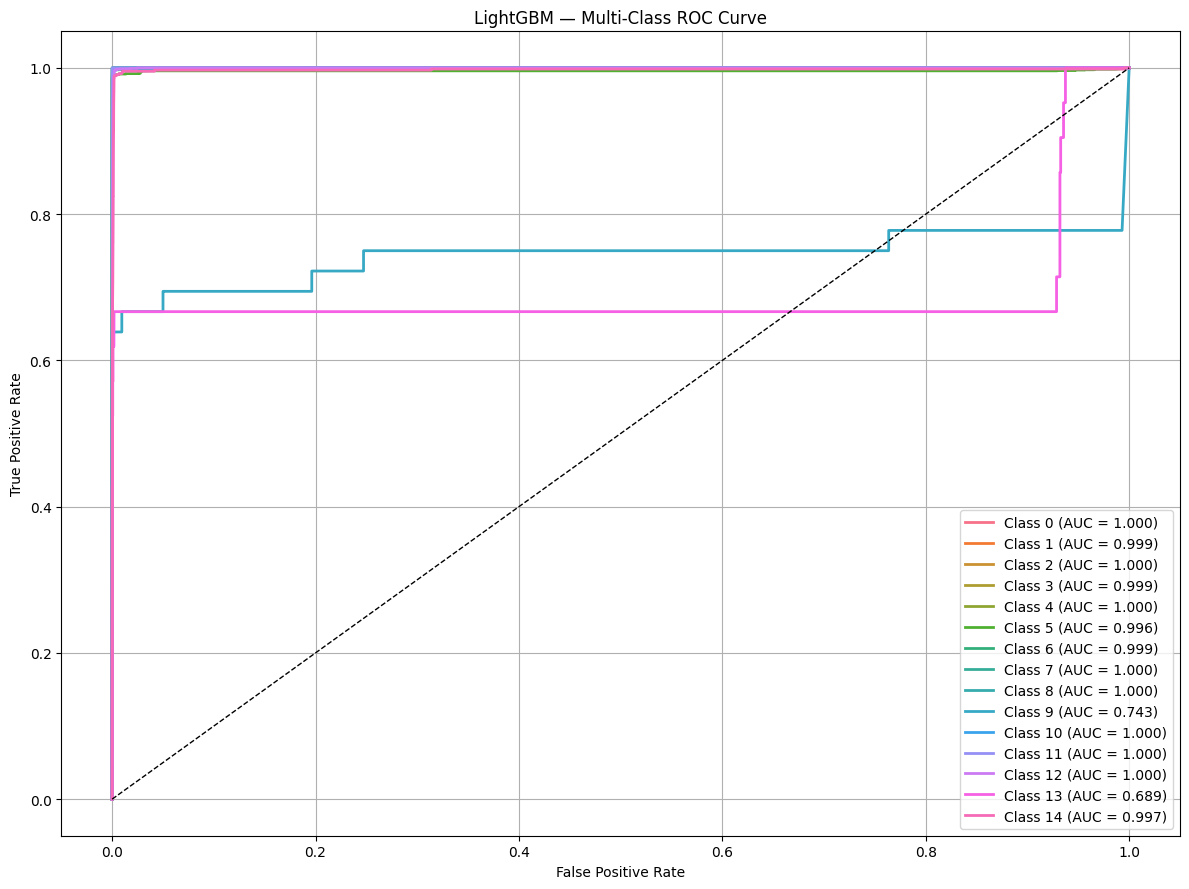

In [13]:
plt.figure(figsize=(12, 9))
y_score = lgb_best.predict_proba(X)

colors = cycle(sns.color_palette("husl", n_classes))
for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, color=color, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.title("LightGBM — Multi-Class ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(RESULTS_DIR, "lgbm_roc_curve.png"), dpi=300)
plt.show()


C:\Users\Maruf\AppData\Local\Temp\ipykernel_16472\3795075473.py:15: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\Maruf\AppData\Local\Temp\ipykernel_16472\3795075473.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(os.path.join(RESULTS_DIR, "lgbm_precision_recall.png"), dpi=300)
C:\Users\Maruf\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


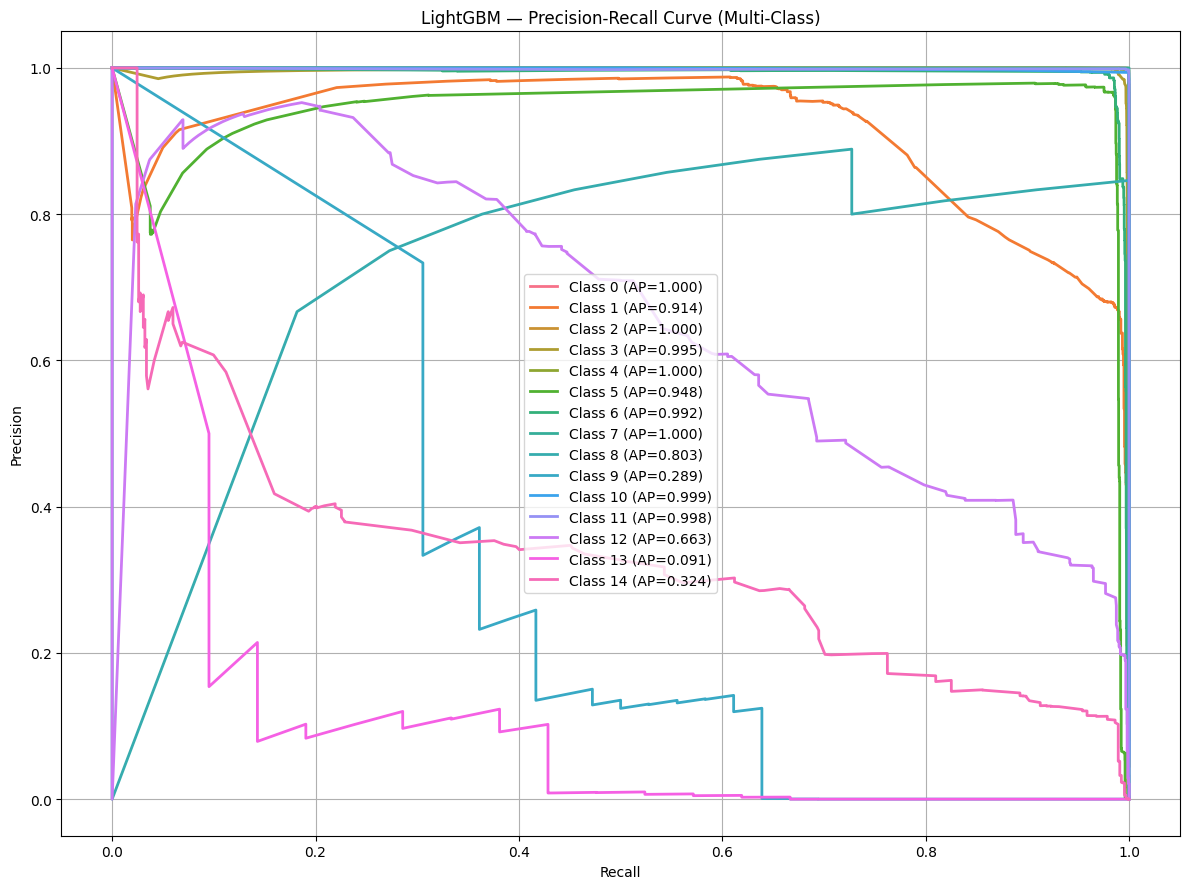

In [14]:
plt.figure(figsize=(12, 9))
colors = cycle(sns.color_palette("husl", n_classes))
y_score = lgb_best.predict_proba(X)

for i, color in zip(range(n_classes), colors):
    precision, recall, _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
    ap = average_precision_score(y_bin[:, i], y_score[:, i])
    plt.plot(recall, precision, lw=2, color=color, label=f"Class {i} (AP={ap:.3f})")

plt.title("LightGBM — Precision-Recall Curve (Multi-Class)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(RESULTS_DIR, "lgbm_precision_recall.png"), dpi=300)
plt.show()


C:\Users\Maruf\AppData\Local\Temp\ipykernel_16472\3362859304.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x="importance", y="feature", palette="viridis")


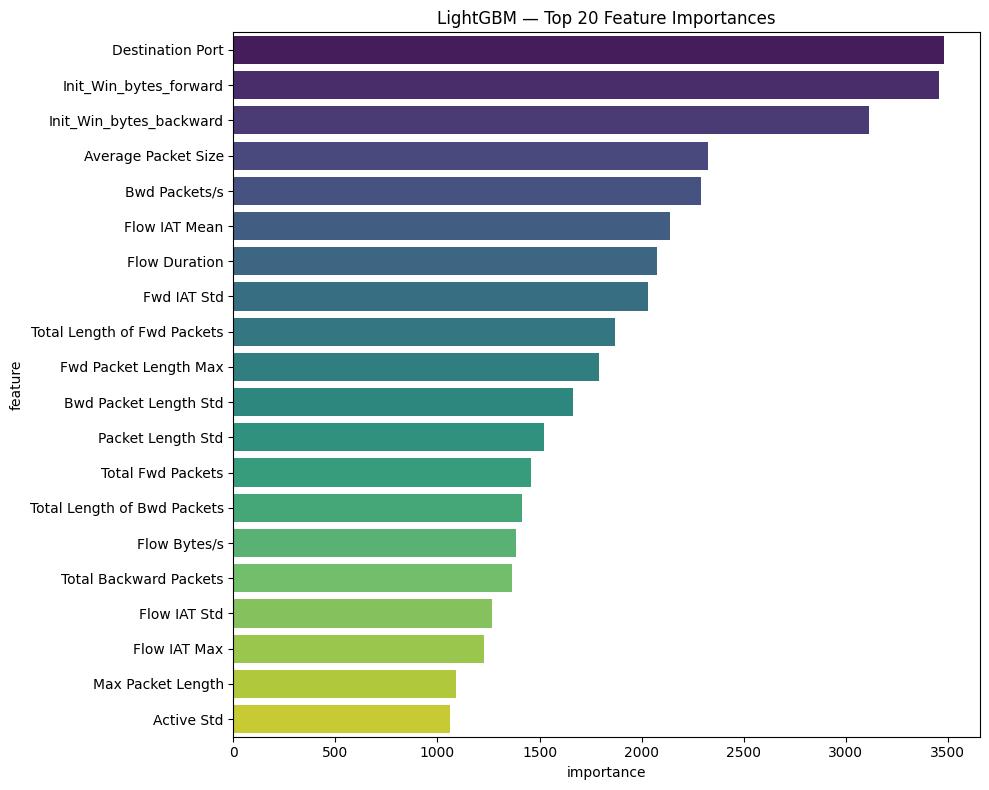

In [15]:
fi = lgb_best.feature_importances_
fi_df = pd.DataFrame({"feature": X.columns, "importance": fi})
fi_df = fi_df.sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=fi_df, x="importance", y="feature", palette="viridis")
plt.title("LightGBM — Top 20 Feature Importances")
plt.tight_layout()

plt.savefig(os.path.join(RESULTS_DIR, "lgbm_feature_importance.png"), dpi=300)
plt.show()


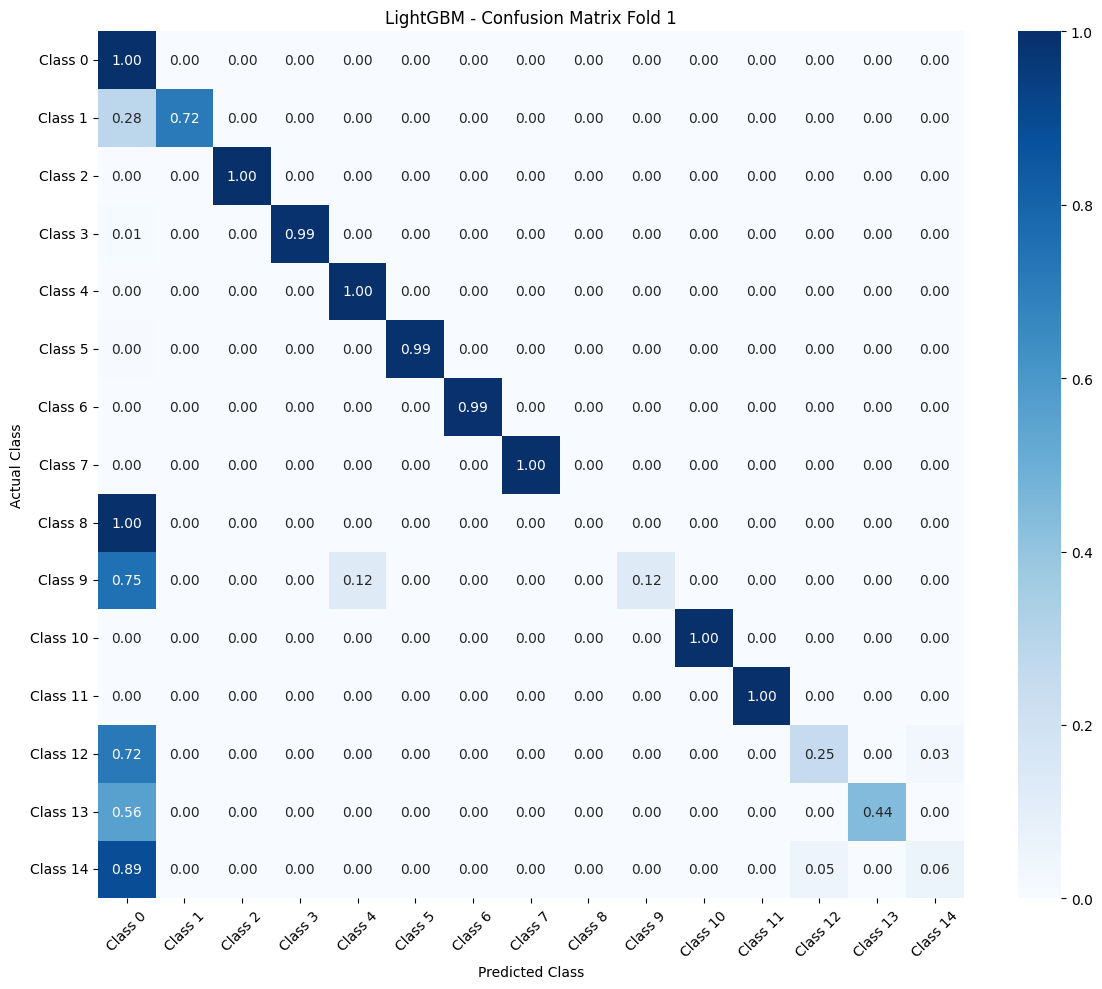

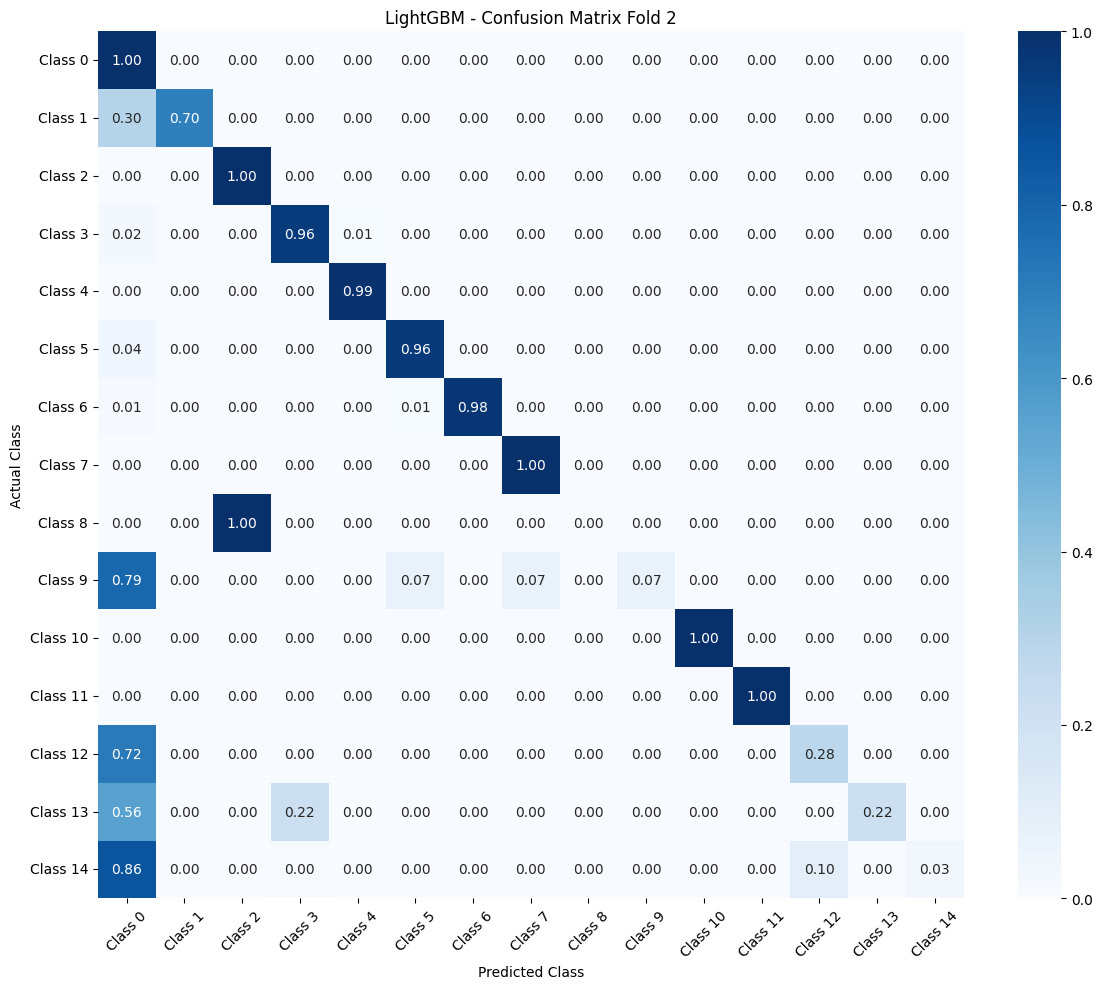

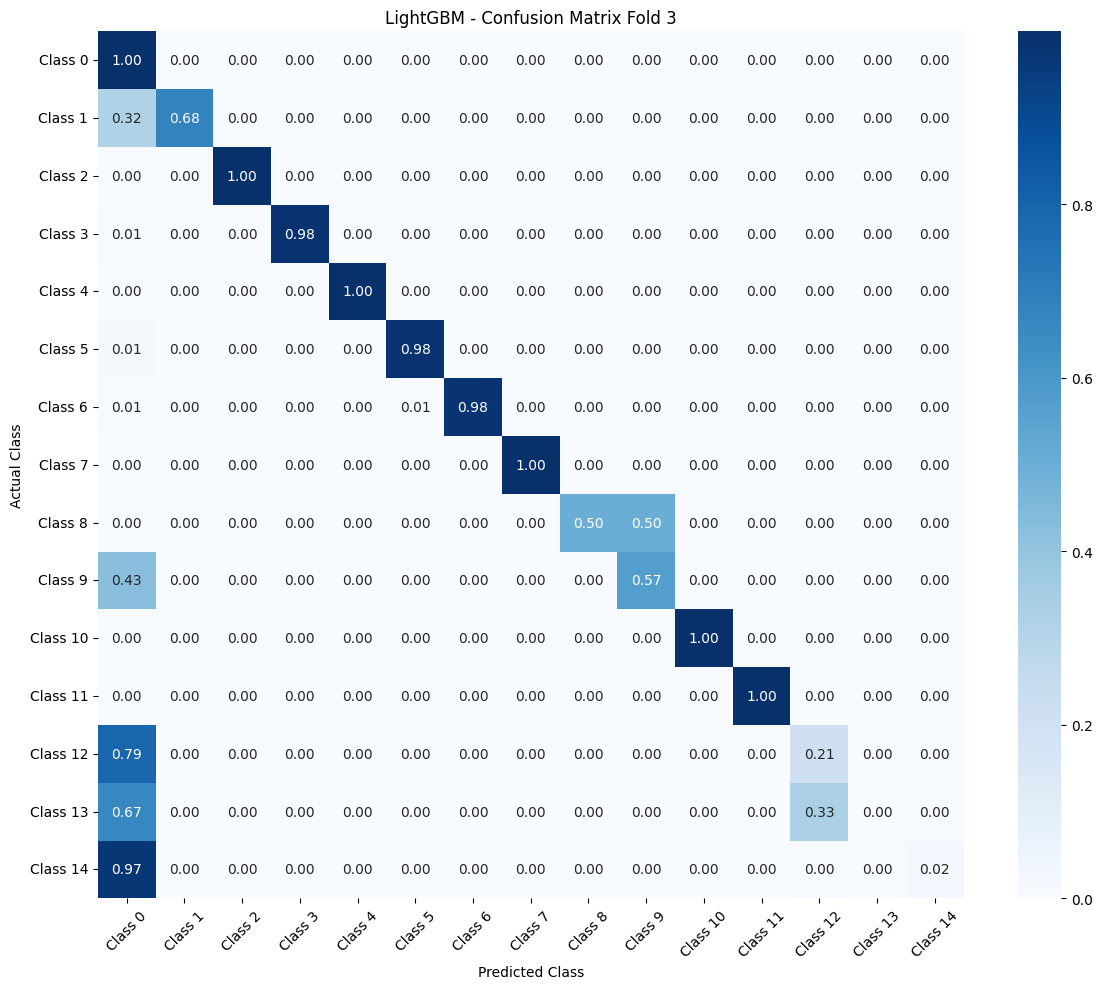

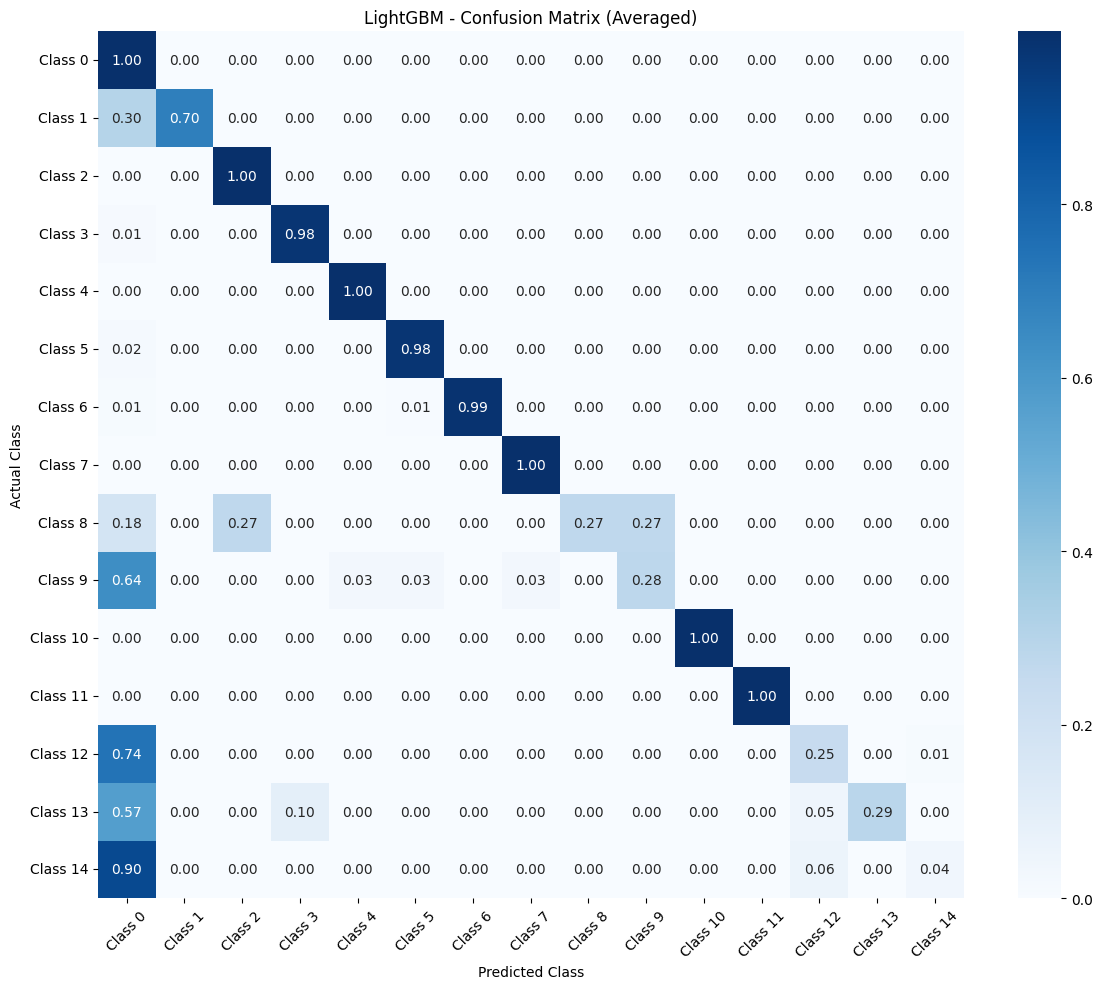

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(cm, class_names=None, fold_num=None, model_name="Model", normalize=True):
    """
    cm: confusion matrix (numpy array)
    class_names: list of class labels
    fold_num: fold number for title (None for averaged matrix)
    model_name: name of the model
    normalize: whether to normalize by row (per-class)
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d", cmap="Blues", cbar=True,
                xticklabels=class_names, yticklabels=class_names)

    title = f"{model_name} - Confusion Matrix"
    if fold_num is not None:
        title += f" Fold {fold_num}"
    else:
        title += " (Averaged)"

    plt.title(title)
    plt.ylabel("Actual Class")
    plt.xlabel("Predicted Class")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Visualize confusion matrices for each fold
conf_matrices = [
    np.array(fold['confusion_matrix']) for fold in metrics_all['LightGBM']
]

class_names = [f"Class {i}" for i in range(conf_matrices[0].shape[0])]  # Replace with actual class names if available

for fold_num, cm in enumerate(conf_matrices, start=1):
    plot_confusion_matrix(cm, class_names=class_names, fold_num=fold_num, model_name="LightGBM")

# Compute and visualize the averaged confusion matrix
max_shape = np.max([cm.shape for cm in conf_matrices], axis=0)
conf_matrices_padded = [
    np.pad(cm, [(0, max_shape[0] - cm.shape[0]), (0, max_shape[1] - cm.shape[1])], mode='constant')
    for cm in conf_matrices
]

avg_conf_matrix = np.mean(conf_matrices_padded, axis=0)
plot_confusion_matrix(avg_conf_matrix, class_names=class_names, fold_num=None, model_name="LightGBM")